# PPA Assessment for Task 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
DIR_REPORT = "../../SiLagoNN/phy/rpt/flat_sweep/"
DIR_LOG = "../../SiLagoNN/exe/log/task4_sweep/"
# print(os.listdir(DIR_REPORT))
LOG_ID = '@[IL2225-Project]'

## Frequency X compilation time

In [3]:
period = np.array([28000, 24000, 20000, 16000, 12000, 8000, 4000])
freq     = 1e-6/(period*1e-12) #[MHz]
exe_time = np.zeros_like(period,dtype=float)

for i,p in enumerate(period):
    with open(DIR_LOG+f'log_{p}.logv') as f:
        lines = f.readlines()
        filtered = np.array(lines[-1][69:78].replace(',', '').strip().split(':'), dtype=int)
        exe_time[i] = (filtered[0]*60) + (filtered[1]) + (filtered[2]/60)

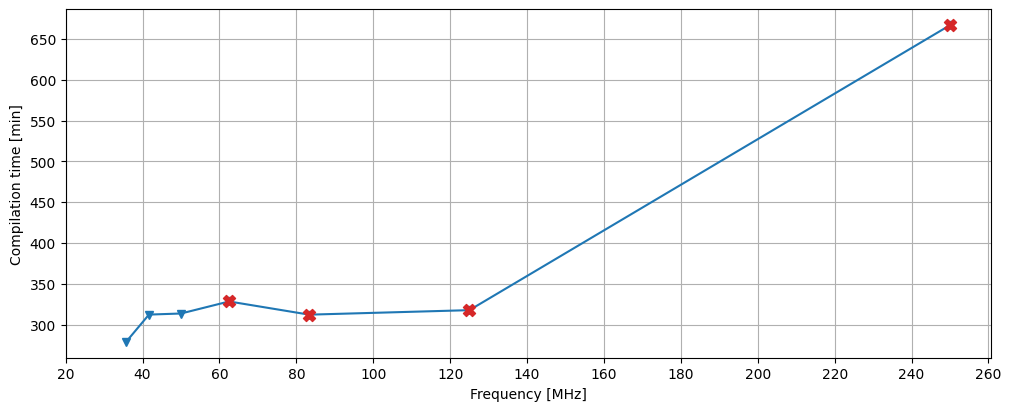

In [4]:
plt.figure(figsize=(10,4), layout='constrained')
plt.plot(freq,exe_time,'v-')
plt.scatter(freq[-4:],exe_time[-4:], marker='X', color='tab:red', s=75, zorder=10)
plt.grid()
plt.xlabel("Frequency [MHz]"); plt.ylabel("Compilation time [min]")
# plt.xticks(freq,rotation=45)
plt.xticks(np.arange(20,260+20,20))
plt.savefig('compile_time.pdf'); plt.show()

## Frequency X Power

In [5]:
power_repartition = {}
for i,T in enumerate(period):
    df = pd.DataFrame([], columns=['Internal Power (mW)', 'Switching Power (mW)', 'Leakage Power (mW)', 'Total Power (mW)', 'Total Power (%)'])
    with open(DIR_REPORT+f'drra_wrapper_power_{T}.txt') as f:
        lines = f.readlines()
        df.loc['Sequential'] = np.array(
            [line.replace('Sequential','').strip().split()
             for line in lines if line.startswith('Sequential')], dtype=float)[0]
        df.loc['IO'] = np.array(
            [line.replace('IO','').strip().split()
             for line in lines if line.startswith('IO')], dtype=float)[0]
        df.loc['Combinational'] = np.array(
            [line.replace('Combinational','').strip().split()
             for line in lines if line.startswith('Combinational')], dtype=float)[0]
        df.loc['Clock'] = np.array(
            [line.replace('Clock (Combinational)','').strip().split()
             for line in lines if line.startswith('Clock (Combinational)')], dtype=float)[0]
        df.loc['Total'] = np.array(
            [line for line in lines if line.startswith('Total')][6].replace('Total','').strip().split(), dtype=float)
    power_repartition[T] = df

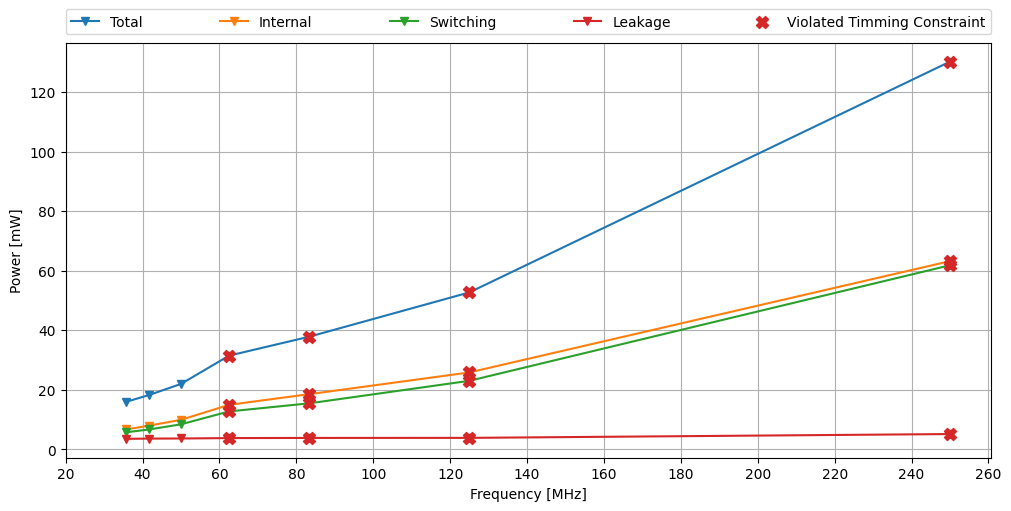

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(10,5), sharex=True, layout='constrained')

axs.plot(
    freq,
    np.array([df.loc['Total', 'Total Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Total'
)
axs.plot(
    freq,
    np.array([df.loc['Total', 'Internal Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Internal'
)
axs.scatter(
    [freq[-1],freq[-2],freq[-3],freq[-4]]*2,
    [power_repartition[period[-1]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-3]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-4]].loc['Total', 'Internal Power (mW)'],
     power_repartition[period[-1]].loc['Total', 'Total Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Total Power (mW)'],
     power_repartition[period[-3]].loc['Total', 'Total Power (mW)'],
     power_repartition[period[-4]].loc['Total', 'Total Power (mW)']], 
    marker='X', color='tab:red', s=75, zorder=10)


axs.plot(
    freq,
    np.array([df.loc['Total', 'Switching Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Switching',
    color='tab:green'
)
axs.plot(
    freq,
    np.array([df.loc['Total', 'Leakage Power (mW)'] for T, df in power_repartition.items()]), 
    'v-',
    label='Leakage',
    color='tab:red'
)
axs.scatter(
    [freq[-1],freq[-2],freq[-3],freq[-4]]*2,
    [power_repartition[period[-1]].loc['Total', 'Switching Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Switching Power (mW)'],
     power_repartition[period[-3]].loc['Total', 'Switching Power (mW)'],
     power_repartition[period[-4]].loc['Total', 'Switching Power (mW)'],
     power_repartition[period[-1]].loc['Total', 'Leakage Power (mW)'],
     power_repartition[period[-2]].loc['Total', 'Leakage Power (mW)'],
     power_repartition[period[-3]].loc['Total', 'Leakage Power (mW)'],
     power_repartition[period[-4]].loc['Total', 'Leakage Power (mW)']], 
    marker='X', color='tab:red', s=75, zorder=10, label='Violated Timming Constraint')


axs.grid()
axs.set_xlabel("Frequency [MHz]"); axs.set_ylabel("Power [mW]"); axs.set_ylabel("Power [mW]")
# axs[1].set_xticks(freq); axs[1].xaxis.set_tick_params(rotation=45)
axs.set_xticks(np.arange(20,260+20,20))
axs.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=5, mode="expand", borderaxespad=0.)
plt.savefig('power.pdf', bbox_inches='tight'); plt.show()

## Frequency X Area

In [7]:
total_area = np.zeros_like(period,dtype=float)
for i,T in enumerate(period):
    with open(DIR_REPORT+f'drra_wrapper_area_{T}.txt') as f:
        total_area[i] = f.readlines()[2].replace('drra_wrapper','').strip().split()[-1]

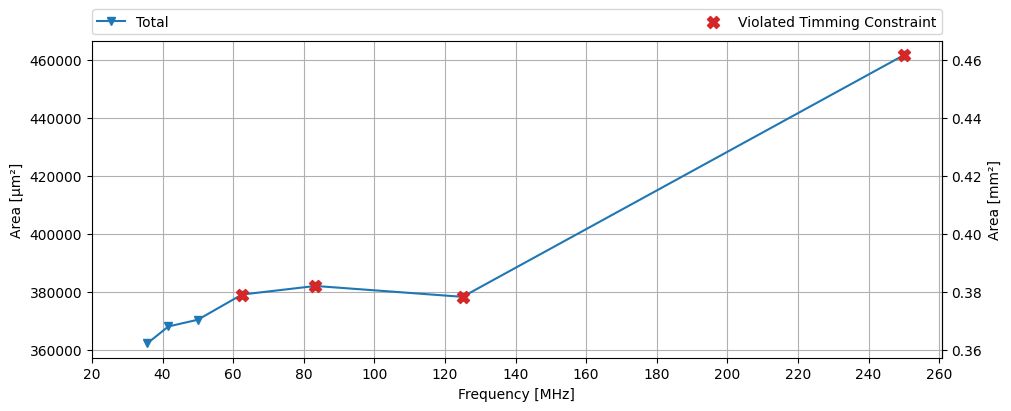

In [8]:
fig, ax = plt.subplots(figsize=(10,4), layout='constrained')

ax.plot(freq, total_area, 'v-', label='Total')

ax.scatter(freq[-4:], total_area[-4:], 
           marker='X', color='tab:red', s=75, zorder=10, label='Violated Timming Constraint')


ax.grid()
ax.set_xlabel("Frequency [MHz]"); ax.set_ylabel("Area [µm²]")
# plt.xticks(freq,rotation=45)
ax.set_xticks(np.arange(20,260+20,20))
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=2, mode="expand", borderaxespad=0.)


def µm2_to_mm2(x):
    return x*1e-6

def mm2_to_µm2(x):
    return x*1e6

secax_y = ax.secondary_yaxis(
    'right', functions=(µm2_to_mm2, mm2_to_µm2))
secax_y.set_ylabel('Area [mm²]')

plt.savefig('area.pdf'); plt.show()